# 實作CycleGAN演算法
### 程式修改自[Cycle GAN with PyTorch](https://towardsdatascience.com/cycle-gan-with-pytorch-ebe5db947a99)

## 載入相關套件

In [ ]:
import os
import random
import shutil
from typing import List, Tuple

import matplotlib.pylab as plt
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

In [2]:
!rm horse2zebra.zip

In [14]:
!ls

horse2zebra	 horses_test   sample_data  zebra_train
horse2zebra.zip  horses_train  zebra_test


## 下載資料集

In [31]:
from google.colab import files
files.upload()

Saving horse2zebra.zip to horse2zebra.zip


In [4]:
# 直接使用gdown指令下載至虛擬機
!wget https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip

--2026-08-14 06:53:52--  https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116867962 (111M) [application/zip]
Saving to: ‘horse2zebra.zip’

horse2zebra.zip     100%[===================>] 111.45M  94.2MB/s    in 1.2s    

2026-08-14 06:53:53 (94.2 MB/s) - ‘horse2zebra.zip’ saved [116867962/116867962]



In [15]:
!ls

horse2zebra	 horses_test   sample_data  zebra_train
horse2zebra.zip  horses_train  zebra_test


## 解壓縮，並重新命名目錄，以利ImageFolder建立dataset

In [6]:
!unzip horse2zebra.zip

Archive:  horse2zebra.zip
   creating: horse2zebra/
   creating: horse2zebra/trainA/
  inflating: horse2zebra/trainA/n02381460_6223.jpg  
  inflating: horse2zebra/trainA/n02381460_1567.jpg  
  inflating: horse2zebra/trainA/n02381460_3354.jpg  
  inflating: horse2zebra/trainA/n02381460_299.jpg  
  inflating: horse2zebra/trainA/n02381460_3001.jpg  
  inflating: horse2zebra/trainA/n02381460_4242.jpg  
  inflating: horse2zebra/trainA/n02381460_1666.jpg  
  inflating: horse2zebra/trainA/n02381460_4396.jpg  
  inflating: horse2zebra/trainA/n02381460_4502.jpg  
  inflating: horse2zebra/trainA/n02381460_8527.jpg  
  inflating: horse2zebra/trainA/n02381460_14.jpg  
  inflating: horse2zebra/trainA/n02381460_706.jpg  
  inflating: horse2zebra/trainA/n02381460_4019.jpg  
  inflating: horse2zebra/trainA/n02381460_1478.jpg  
  inflating: horse2zebra/trainA/n02381460_3449.jpg  
  inflating: horse2zebra/trainA/n02381460_5558.jpg  
  inflating: horse2zebra/trainA/n02381460_969.jpg  
  inflating: horse2

In [ ]:
shutil.move("horse2zebra/trainA", "horses_train/A")
shutil.move("horse2zebra/trainB", "zebra_train/B")
shutil.move("horse2zebra/testA", "horses_test/A")
shutil.move("horse2zebra/testB", "zebra_test/B")

'zebra_test/B'

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'
device

'cuda'

In [16]:
!ls horses_train

A


## 建立 dataset、data loader

torch.Size([5, 3, 256, 256])


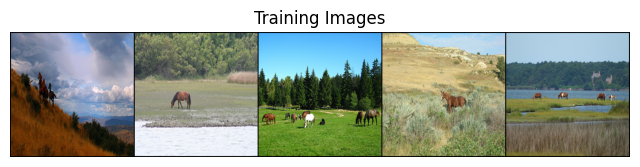

In [ ]:
bs = 5
workers = 2
image_size = (256, 256)
dataroot = 'horses_train/'
dataset_horses_train = datasets.ImageFolder(
    dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_train_horses = DataLoader(dataset_horses_train, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_train_horses))
print(real_batch[0].shape)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(
    np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0))
)

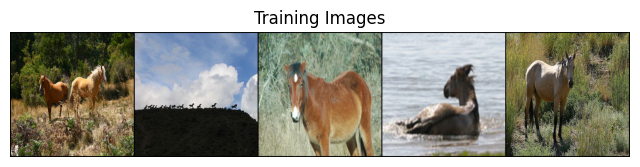

In [ ]:
dataroot = 'horses_test/'
dataset_horses_test = datasets.ImageFolder(
    root=dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_test_horses = DataLoader(dataset_horses_test, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_test_horses))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0)))

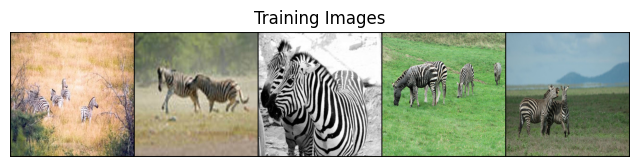

In [ ]:
dataroot = 'zebra_train'
dataset_zebra_train = datasets.ImageFolder(
    root=dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_zebra_train = DataLoader(dataset_zebra_train, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_zebra_train))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0)))

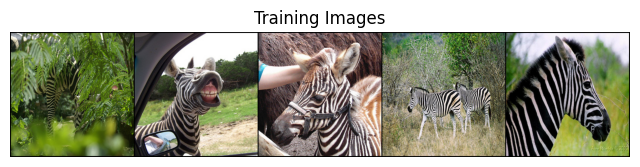

In [ ]:
dataroot = 'zebra_test'
dataset_zebra_test = datasets.ImageFolder(
    root=dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_zebra_test = DataLoader(dataset_zebra_test, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_zebra_test))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0)))

## 定義繪製4個影像的函數：真實的馬、生成的斑馬、真實的斑馬、生成的馬

In [ ]:
def plot_images_test(dataloader_test_horses: DataLoader, dataloader_zebra_test: DataLoader) -> None:
    batch_a_test: torch.Tensor = next(iter(dataloader_test_horses))[0].to(device)
    real_a_test = batch_a_test.cpu().detach()
    # 將馬變成斑馬
    fake_b_test: torch.Tensor = G_A2B(batch_a_test).cpu().detach()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((real_a_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Real horses")
    plt.show()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((fake_b_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Fake zebras")
    plt.show()

    batch_b_test: torch.Tensor = next(iter(dataloader_zebra_test))[0].to(device)
    real_b_test = batch_b_test.cpu().detach()
    # 將斑馬變成馬
    fake_a_test: torch.Tensor = G_B2A(batch_b_test).cpu().detach()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((real_b_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Real zebras")
    plt.show()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((fake_a_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Fake horses")
    plt.show()

## 定義繪製8個影像的函數

In [ ]:
def plot_all_images(image_number: int, dataloader_test_horses: DataLoader, dataloader_zebra_test: DataLoader) -> None:
    # generate fake zebras
    batch_a_test = next(iter(dataloader_test_horses))[0].to(device)
    real_a_test = batch_a_test.cpu().detach()
    fake_b_test = G_A2B(batch_a_test).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((real_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Real horses")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((fake_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Fake zebras")
    plt.show()
    # generate fake horses
    batch_b_test = next(iter(dataloader_zebra_test))[0].to(device)
    real_b_test = batch_b_test.cpu().detach()
    fake_a_test = G_B2A(batch_b_test).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((real_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Real zebras")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((fake_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Fake horses")
    plt.show()
    # identity
    identity_a_test = G_B2A(batch_a_test.cuda()).cpu().detach()
    identity_b_test = G_A2B(batch_b_test.cuda()).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((identity_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Identity horses")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((identity_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Identity zebras")
    plt.show()
    # recovered image
    recover_a_test = G_B2A(fake_b_test.cuda()).cpu().detach()
    recover_b_test = G_A2B(fake_a_test.cuda()).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((recover_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Recovered horses")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((recover_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Recovered zebras")
    plt.show()

## 定義模型存檔與載入的函數

In [ ]:
def save_models(G_A2B: nn.Module, G_B2A: nn.Module, D_A: nn.Module, D_B: nn.Module, name: str) -> None:
    torch.save(G_A2B, "/content/gdrive/My Drive/model_proj3/" + name + "_G_A2B.pt")
    torch.save(G_B2A, "/content/gdrive/My Drive/model_proj3/" + name + "_G_B2A.pt")
    torch.save(D_A, "/content/gdrive/My Drive/model_proj3/" + name + "_D_A.pt")
    torch.save(D_B, "/content/gdrive/My Drive/model_proj3/" + name + "_D_B.pt")


def load_models(name: str) -> Tuple[nn.Module, nn.Module, nn.Module, nn.Module]:
    G_A2B = torch.load("/content/gdrive/My Drive/model_proj3/" + name + "_G_A2B.pt")
    G_B2A = torch.load("/content/gdrive/My Drive/model_proj3/" + name + "_G_B2A.pt")
    D_A = torch.load("/content/gdrive/My Drive/model_proj3/" + name + "_D_A.pt")
    D_B = torch.load("/content/gdrive/My Drive/model_proj3/" + name + "_D_B.pt")
    return G_A2B, G_B2A, D_A, D_B


# save_models(G_A2B, G_B2A, D_A, D_B, "test")
# G_A2B, G_B2A, D_A, D_B= load_models("test")

## 定義生成網路訓練函數

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, f):
        super(ResBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(f, f, 3, 1, 1),
            nn.InstanceNorm2d(f),
            nn.ReLU(),
            nn.Conv2d(f, f, 3, 1, 1),
        )
        self.norm = nn.InstanceNorm2d(f)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.norm(self.conv(x) + x))


class Generator(nn.Module):
    def __init__(self, f=64, blocks=9):
        super(Generator, self).__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, f, 7, 1, 0),
            nn.InstanceNorm2d(f),
            nn.ReLU(True),
            nn.Conv2d(f, 2 * f, 3, 2, 1),
            nn.InstanceNorm2d(2 * f),
            nn.ReLU(True),
            nn.Conv2d(2 * f, 4 * f, 3, 2, 1),
            nn.InstanceNorm2d(4 * f),
            nn.ReLU(True),
        ]
        for i in range(int(blocks)):
            layers.append(ResBlock(4 * f))
        layers.extend(
            [
                nn.ConvTranspose2d(4 * f, 4 * 2 * f, 3, 1, 1),
                nn.PixelShuffle(2),
                nn.InstanceNorm2d(2 * f),
                nn.ReLU(True),
                nn.ConvTranspose2d(2 * f, 4 * f, 3, 1, 1),
                nn.PixelShuffle(2),
                nn.InstanceNorm2d(f),
                nn.ReLU(True),
                nn.ReflectionPad2d(3),
                nn.Conv2d(f, 3, 7, 1, 0),
                nn.Tanh(),
            ]
        )
        self.conv = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)

## 定義判別網路訓練函數

In [ ]:
nc = 3
ndf = 64


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 128 x 128
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 64 x 64
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 32 x 32
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 16 x 16
            nn.Conv2d(ndf * 4, ndf * 8, 4, 1, 1),
            nn.InstanceNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 15 x 15
            nn.Conv2d(ndf * 8, 1, 4, 1, 1),
            # state size. 1 x 14 x 14
        )

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        return self.main(input)

## 定義判別網路及生成網路的損失函數

In [ ]:
def LSGAN_D(real: torch.Tensor, fake: torch.Tensor) -> torch.Tensor:
    return torch.mean((real - 1) ** 2) + torch.mean(fake**2)


def LSGAN_G(fake: torch.Tensor) -> torch.Tensor:
    return torch.mean((fake - 1) ** 2)

## 建立判別及生成網路

In [ ]:
G_A2B = Generator().to(device)
G_B2A = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

# Initialize Loss function
criterion_Im = nn.L1Loss()

# Learning rate for optimizers
lr = 0.0002

# Optimizers
# optimizer_G = optim.Adam(itertools.chain(G_A2B.parameters(), G_B2A.parameters()),
#                                lr=lr, betas=(0.5, 0.999))
optimizer_G_A2B = optim.Adam(G_A2B.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_G_B2A = optim.Adam(G_B2A.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=lr, betas=(0.5, 0.999))

## 定義訓練模型的函數

In [ ]:
def training(
    G_A2B: nn.Module,
    G_B2A: nn.Module,
    D_A: nn.Module,
    D_B: nn.Module,
    num_epochs: int,
    name: str,
    old: bool = True,
) -> Tuple[List, List, List, List, List, List, List, List]:
    # Lists to keep track of progress
    img_list = []
    G_losses = []
    D_A_losses = []
    D_B_losses = []

    iters = 0
    FDL_A2B = []
    FDL_B2A = []
    CL_A = []
    CL_B = []
    ID_B2A = []
    ID_A2B = []
    disc_A = []
    disc_B = []

    FDL_A2B_t = []
    FDL_B2A_t = []
    CL_A_t = []
    CL_B_t = []
    ID_B2A_t = []
    ID_A2B_t = []
    disc_A_t = []
    disc_B_t = []

    print("Starting Training Loop...")
    old_a_fake = torch.empty(0)
    old_b_fake = torch.empty(0)
    epoch = 0
    # For each epoch
    for epoch in range(num_epochs):
        # For each batch in the dataloader
        for i, (data_horse, data_zebra) in enumerate(zip(dataloader_train_horses, dataloader_zebra_train), 0):

            # Set model input
            a_real = data_horse[0].to(device)
            b_real = data_zebra[0].to(device)

            tensor_ones = torch.ones([a_real.shape[0], 1, 14, 14]).cuda()
            tensor_zeros = torch.zeros([a_real.shape[0], 1, 14, 14]).cuda()

            # Genrated images
            b_fake = G_A2B(a_real)
            a_rec = G_B2A(b_fake)
            a_fake = G_B2A(b_real)
            b_rec = G_A2B(a_fake)

            # Discriminator A
            optimizer_D_A.zero_grad()
            if (iters > 0 or epoch > 0) and old and iters % 3 == 0:
                rand_int = random.randint(5, old_a_fake.shape[0] - 1)
                Disc_loss_A = LSGAN_D(D_A(a_real), D_A(old_a_fake[rand_int - 5 : rand_int].detach()))
                D_A_losses.append(Disc_loss_A.item())
            else:
                Disc_loss_A = LSGAN_D(D_A(a_real), D_A(a_fake.detach()))
                D_A_losses.append(Disc_loss_A.item())

            Disc_loss_A.backward()
            optimizer_D_A.step()

            # Discriminator B
            optimizer_D_B.zero_grad()
            if (iters > 0 or epoch > 0) and old and iters % 3 == 0:
                rand_int = random.randint(5, old_b_fake.shape[0] - 1)
                Disc_loss_B = LSGAN_D(D_B(b_real), D_B(old_b_fake[rand_int - 5 : rand_int].detach()))
                D_B_losses.append(Disc_loss_B.item())
            else:
                Disc_loss_B = LSGAN_D(D_B(b_real), D_B(b_fake.detach()))
                D_B_losses.append(Disc_loss_B.item())

            Disc_loss_B.backward()
            optimizer_D_B.step()

            # Generator
            optimizer_G_A2B.zero_grad()
            optimizer_G_B2A.zero_grad()

            # Fool discriminator
            Fool_disc_loss_A2B = LSGAN_G(D_B(b_fake))
            Fool_disc_loss_B2A = LSGAN_G(D_A(a_fake))

            # Cycle Consistency    both use the two generators
            Cycle_loss_A = criterion_Im(a_rec, a_real) * 5
            Cycle_loss_B = criterion_Im(b_rec, b_real) * 5

            # Identity loss
            Id_loss_B2A = criterion_Im(G_B2A(a_real), a_real) * 10
            Id_loss_A2B = criterion_Im(G_A2B(b_real), b_real) * 10

            # generator losses
            Loss_G = Fool_disc_loss_A2B + Fool_disc_loss_B2A + Cycle_loss_A + Cycle_loss_B + Id_loss_B2A + Id_loss_A2B
            G_losses.append(Loss_G)

            # Backward propagation
            Loss_G.backward()

            # Optimisation step
            optimizer_G_A2B.step()
            optimizer_G_B2A.step()

            FDL_A2B.append(Fool_disc_loss_A2B)
            FDL_B2A.append(Fool_disc_loss_B2A)
            CL_A.append(Cycle_loss_A)
            CL_B.append(Cycle_loss_B)
            ID_B2A.append(Id_loss_B2A)
            ID_A2B.append(Id_loss_A2B)
            disc_A.append(Disc_loss_A)
            disc_B.append(Disc_loss_B)

            if iters == 0 and epoch == 0:
                old_b_fake = b_fake.clone()
                old_a_fake = a_fake.clone()
            elif old_b_fake.shape[0] == bs * 5 and b_fake.shape[0] == bs:
                rand_int = random.randint(5, 24)
                old_b_fake[rand_int - 5 : rand_int] = b_fake.clone()
                old_a_fake[rand_int - 5 : rand_int] = a_fake.clone()
            elif old_b_fake.shape[0] < 25:
                old_b_fake = torch.cat((b_fake.clone(), old_b_fake))
                old_a_fake = torch.cat((a_fake.clone(), old_a_fake))

            iters += 1
            del data_zebra, data_horse, a_real, b_real, a_fake, b_fake

            if iters % 50 == 0:
                print(
                    f'[{epoch + 1}/{num_epochs}]\tFDL_A2B: {Fool_disc_loss_A2B:.4f}\tFDL_B2A: {Fool_disc_loss_B2A:.4f}\t'
                    f'CL_A: {Cycle_loss_A:.4f}\tCL_B: {Cycle_loss_B:.4f}\tID_B2A: {Id_loss_B2A:.4f}\tID_A2B: {Id_loss_A2B:.4f}\t'
                    f'Loss_D_A: {Disc_loss_A.item():.4f}\tLoss_D_A: {Disc_loss_B.item():.4f}'
                )

    FDL_A2B_t.append(sum(FDL_A2B) / len(FDL_A2B))
    FDL_B2A_t.append(sum(FDL_B2A) / len(FDL_B2A))
    CL_A_t.append(sum(CL_A) / len(CL_A))
    CL_B_t.append(sum(CL_B) / len(CL_B))
    ID_B2A_t.append(sum(ID_B2A) / len(ID_B2A))
    ID_A2B_t.append(sum(ID_A2B) / len(ID_A2B))
    disc_A_t.append(sum(disc_A) / len(disc_A))
    disc_B_t.append(sum(disc_B) / len(disc_B))

    FDL_A2B = []
    FDL_B2A = []
    CL_A = []
    CL_B = []
    ID_B2A = []
    ID_A2B = []
    disc_B = []
    disc_A = []

    iters = 0
    save_models(G_A2B, G_B2A, D_A, D_B, name)
    if epoch % 5 == 0:
        plot_images_test(dataloader_test_horses, dataloader_zebra_test)
    # plot_all_images(4, dataloader_test_horses, dataloader_zebra_test)
    return (FDL_A2B_t, FDL_B2A_t, CL_A_t, CL_B_t, ID_B2A_t, ID_A2B_t, disc_A_t, disc_B_t)

In [ ]:
name = 'basic_training50'
epochs = 20
losses = training(G_A2B, G_B2A, D_A, D_B, epochs, name)

Starting Training Loop...


/tmp/ipykernel_7452/3429344873.py:124: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  '[%d/%d]\tFDL_A2B: %.4f\tFDL_B2A: %.4f\tCL_A: %.4f\tCL_B: %.4f\tID_B2A: %.4f\tID_A2B: %.4f\tLoss_D_A: %.4f\tLoss_D_A: %.4f'


[1/20]	FDL_A2B: 0.4839	FDL_B2A: 0.3392	CL_A: 0.7252	CL_B: 0.6857	ID_B2A: 1.1493	ID_A2B: 1.2771	Loss_D_A: 0.4978	Loss_D_A: 0.4634
[1/20]	FDL_A2B: 0.2343	FDL_B2A: 0.2848	CL_A: 0.7969	CL_B: 0.7661	ID_B2A: 1.2505	ID_A2B: 1.2230	Loss_D_A: 0.4025	Loss_D_A: 0.4703
[1/20]	FDL_A2B: 0.5001	FDL_B2A: 0.2945	CL_A: 0.5750	CL_B: 0.7104	ID_B2A: 0.8834	ID_A2B: 1.3122	Loss_D_A: 0.4653	Loss_D_A: 0.3904
[1/20]	FDL_A2B: 0.2811	FDL_B2A: 0.4810	CL_A: 0.5829	CL_B: 0.6082	ID_B2A: 1.0984	ID_A2B: 1.0321	Loss_D_A: 0.5010	Loss_D_A: 0.5064
[2/20]	FDL_A2B: 0.2899	FDL_B2A: 0.4589	CL_A: 0.5602	CL_B: 0.6775	ID_B2A: 0.9849	ID_A2B: 1.1552	Loss_D_A: 0.7072	Loss_D_A: 0.4521
[2/20]	FDL_A2B: 0.3200	FDL_B2A: 0.2695	CL_A: 0.5963	CL_B: 0.7821	ID_B2A: 0.9637	ID_A2B: 1.1774	Loss_D_A: 0.4890	Loss_D_A: 0.4429
[2/20]	FDL_A2B: 0.4276	FDL_B2A: 0.5722	CL_A: 0.5997	CL_B: 0.5952	ID_B2A: 1.1671	ID_A2B: 1.0039	Loss_D_A: 0.4427	Loss_D_A: 0.3187
[2/20]	FDL_A2B: 0.2505	FDL_B2A: 0.1733	CL_A: 0.5394	CL_B: 0.8085	ID_B2A: 0.8268	ID_A2B: 1.4196	Lo

## 存檔

In [ ]:
if not os.path.exists('CycleGAN'):
    os.makedirs('CycleGAN')
# save last check pointing
torch.save(G_A2B.state_dict(), f"CycleGAN/netG_A2B.pth")
torch.save(G_B2A.state_dict(), f"CycleGAN/netG_B2A.pth")
torch.save(D_A.state_dict(), f"CycleGAN/netD_A.pth")
torch.save(D_B.state_dict(), f"CycleGAN/netD_B.pth")

In [ ]:
# 壓縮相關模型
!zip CycleGAN.zip CycleGAN/*.*

In [ ]:
from google.colab import files
files.download('CycleGAN.zip')